In [23]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state = torch.load("E:/icu_project/session_state.pt", weights_only=True)

X = state["X"]
mask = state["mask"]
delta = state["delta"]
y = state["y"]
static = state["static"]

X_train = state["X_train"]
X_test = state["X_test"]

mask_train = state["mask_train"]
mask_test = state["mask_test"]

delta_train = state["delta_train"]
delta_test = state["delta_test"]

static_train = state["static_train"]
static_test = state["static_test"]

y_train = state["y_train"]
y_test = state["y_test"]

print("Session loaded")

Session loaded


In [24]:
import torch.nn as nn

class BiGRUAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask], dim=2)

        h0 = torch.tanh(self.static_init(static))
        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        attn = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn * out, dim=1)

        logits = self.classifier(context)

        return logits

In [25]:
input_dim = X.shape[2]

model = BiGRUAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

model.load_state_dict(state["model_state"])

model.eval()

print("Model restored")

Model restored


In [26]:
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):

    def __init__(self, X, mask, delta, static, y):
        self.X = X
        self.mask = mask
        self.delta = delta
        self.static = static
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.mask[idx],
            self.delta[idx],
            self.static[idx],
            self.y[idx]
        )

test_dataset = ICUDataset(
    X_test,
    mask_test,
    delta_test,
    static_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [3]:
import os
print(os.getcwd())

C:\Users\pande


In [4]:
import pandas as pd

icu_hourly = pd.read_csv("data/processed_icu_hourly_v1.csv")

print(icu_hourly.shape)
icu_hourly.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed_icu_hourly_v1.csv'

In [ ]:
patients = pd.read_csv("data/eicu_demo/patient.csv")

patients[["patientunitstayid", "hospitaldischargestatus"]].head()

In [ ]:
patients["hospitaldischargestatus"].value_counts()

In [ ]:
patients["mortality"] = (
    patients["hospitaldischargestatus"]
    .map({"Alive": 0, "Expired": 1})
)

patients["mortality"].value_counts()

In [ ]:
icu_labeled = icu_hourly.merge(
    patients[["patientunitstayid", "mortality"]],
    on="patientunitstayid",
    how="left"
)

print("Total rows:", icu_labeled.shape[0])
print("Unique patients:", icu_labeled["patientunitstayid"].nunique())
print("Mortality distribution:")
print(icu_labeled["mortality"].value_counts())

In [ ]:
import numpy as np

unique_patients = icu_labeled["patientunitstayid"].unique()

np.random.seed(42)
np.random.shuffle(unique_patients)

split_index = int(0.8 * len(unique_patients))

train_patients = unique_patients[:split_index]
test_patients = unique_patients[split_index:]

print("Train patients:", len(train_patients))
print("Test patients:", len(test_patients))

In [ ]:
train_df = icu_labeled[
    icu_labeled["patientunitstayid"].isin(train_patients)
]

test_df = icu_labeled[
    icu_labeled["patientunitstayid"].isin(test_patients)
]

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])

In [ ]:
X_train = train_df.drop(columns=["patientunitstayid", "mortality"])
y_train = train_df["mortality"]

X_test = test_df.drop(columns=["patientunitstayid", "mortality"])
y_test = test_df["mortality"]

print(X_train.shape)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Imputer
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
icu_labeled["mortality"].isna().sum()

In [ ]:
icu_labeled = icu_labeled.dropna(subset=["mortality"])

print("New shape:", icu_labeled.shape)
print("Mortality distribution:")
print(icu_labeled["mortality"].value_counts())

In [ ]:
unique_patients = icu_labeled["patientunitstayid"].unique()

np.random.seed(42)
np.random.shuffle(unique_patients)

split_index = int(0.8 * len(unique_patients))

train_patients = unique_patients[:split_index]
test_patients = unique_patients[split_index:]

train_df = icu_labeled[
    icu_labeled["patientunitstayid"].isin(train_patients)
]

test_df = icu_labeled[
    icu_labeled["patientunitstayid"].isin(test_patients)
]

X_train = train_df.drop(columns=["patientunitstayid", "mortality"])
y_train = train_df["mortality"]

X_test = test_df.drop(columns=["patientunitstayid", "mortality"])
y_test = test_df["mortality"]

print("Train rows:", X_train.shape)
print("Test rows:", X_test.shape)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logreg.fit(X_train_scaled, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_imputed, y_train)

y_pred_rf = rf.predict(X_test_imputed)
y_prob_rf = rf.predict_proba(X_test_imputed)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
import numpy as np

# Try lower threshold
threshold = 0.3

y_pred_adj = (y_prob >= threshold).astype(int)

print("Adjusted Threshold:", threshold)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adj))

In [ ]:
import numpy as np

# Try lower threshold
threshold = 0.2

y_pred_adj = (y_prob >= threshold).astype(int)

print("Adjusted Threshold:", threshold)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adj))

In [ ]:
patient_hours = icu_hourly.groupby("patientunitstayid")["hour"].max()

print("Total patients:", len(patient_hours))
print("Patients with >=24h:", (patient_hours >= 24).sum())

In [ ]:
# Patients with at least 24 hours
valid_patients = patient_hours[patient_hours >= 24].index

icu_24 = icu_hourly[
    icu_hourly["patientunitstayid"].isin(valid_patients)
]

print("Rows:", icu_24.shape)
print("Patients:", icu_24["patientunitstayid"].nunique())

In [ ]:
icu_24 = icu_24[icu_24["hour"] < 24]
print(icu_24["hour"].max())

In [ ]:
icu_24 = icu_24.merge(
    patients[["patientunitstayid", "mortality"]],
    on="patientunitstayid",
    how="left"
)

print(icu_24["mortality"].isna().sum())

In [ ]:
icu_24 = icu_24.dropna(subset=["mortality"])

print("Rows after drop:", icu_24.shape)
print("Unique patients:", icu_24["patientunitstayid"].nunique())

In [ ]:
hours_per_patient = icu_24.groupby("patientunitstayid")["hour"].count()

print("Patients with exactly 24 rows:",
      (hours_per_patient == 24).sum())

print("Patients with less than 24 rows:",
      (hours_per_patient < 24).sum())

In [ ]:
print(icu_hourly.shape)
print(icu_hourly["patientunitstayid"].nunique())

In [ ]:
icu_24 = icu_hourly[icu_hourly["hour"] < 24]

In [ ]:
hours_per_patient = (
    icu_24.groupby("patientunitstayid")["hour"]
    .nunique()
)

print("Patients with 24 distinct hours:",
      (hours_per_patient == 24).sum())

In [ ]:
valid_patients = hours_per_patient[hours_per_patient == 24].index

icu_seq = icu_24[
    icu_24["patientunitstayid"].isin(valid_patients)
]

print("Rows:", icu_seq.shape)
print("Patients:", icu_seq["patientunitstayid"].nunique())

In [ ]:
icu_seq = icu_seq.merge(
    patients[["patientunitstayid", "mortality"]],
    on="patientunitstayid",
    how="left"
)

print("Missing mortality:", icu_seq["mortality"].isna().sum())

In [ ]:
icu_seq = icu_seq.dropna(subset=["mortality"])

print("Rows after drop:", icu_seq.shape)
print("Patients after drop:", icu_seq["patientunitstayid"].nunique())

In [ ]:
hours_check = icu_seq.groupby("patientunitstayid")["hour"].nunique()

print("Patients with full 24h:",
      (hours_check == 24).sum())

print("Any incomplete left:",
      (hours_check < 24).sum())

In [ ]:
icu_seq = icu_seq.sort_values(["patientunitstayid", "hour"])


In [ ]:
feature_cols = [
    col for col in icu_seq.columns
    if col not in ["patientunitstayid", "hour", "mortality"]
]

print("Feature count:", len(feature_cols))

In [ ]:
import numpy as np

patients_unique = icu_seq["patientunitstayid"].unique()

X_list = []
y_list = []

for pid in patients_unique:
    patient_data = icu_seq[icu_seq["patientunitstayid"] == pid]
    
    X_list.append(patient_data[feature_cols].values)
    y_list.append(patient_data["mortality"].iloc[0])

X_seq = np.array(X_list)
y_seq = np.array(y_list)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

In [ ]:
import os
os.getcwd()

In [ ]:
os.listdir()

In [ ]:
for root, dirs, files in os.walk("E:/"):
    for file in files:
        if "processed_icu_hourly_v1.csv" in file:
            print(os.path.join(root, file))

In [ ]:
import pandas as pd

df = pd.read_csv(r"E:\icu_project\data\processed_icu_hourly_v1.csv")

In [ ]:
print(df.shape)
print(df.columns)

In [ ]:
print(df.columns)

In [ ]:
import os

for root, dirs, files in os.walk(r"E:\icu_project"):
    for file in files:
        if "patient" in file.lower():
            print(os.path.join(root, file))

In [ ]:
import pandas as pd

patient_df = pd.read_csv(r"E:\icu_project\data\eicu_demo\patient.csv")

In [ ]:
print(patient_df.columns)

In [ ]:
patient_df = patient_df[[
    "patientunitstayid",
    "hospitaldischargestatus"
]]

patient_df["mortality"] = (
    patient_df["hospitaldischargestatus"] == "Expired"
).astype(int)

patient_df = patient_df[[
    "patientunitstayid",
    "mortality"
]]

In [ ]:
print(patient_df["mortality"].value_counts())

In [ ]:
df = df.merge(
    patient_df,
    on="patientunitstayid",
    how="left"
)

In [ ]:
print(df["mortality"].isna().sum())
print(df["mortality"].value_counts())

In [ ]:
df.to_csv(
    r"E:\icu_project\data\processed_icu_hourly_v2.csv",
    index=False
)

In [ ]:
import numpy as np

feature_cols = [
    "heartrate","respiration","sao2","BUN","creatinine",
    "sodium","potassium","magnesium",
    "Hct","Hgb","WBC x 1000","platelets x 1000",
    "HCO3","pH"
]

patients = []

for pid, group in df.groupby("patientunitstayid"):
    group = group.sort_values("hour")
    if len(group) == 24 and set(group["hour"]) == set(range(24)):
        patients.append(group)

df_24 = pd.concat(patients)

X = []
y = []

for pid, group in df_24.groupby("patientunitstayid"):
    X.append(group[feature_cols].values)
    y.append(group["mortality"].iloc[0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Mortality rate:", y.mean())

In [ ]:
import os
os.listdir(r"E:\icu_project\data\challenge2012")

In [ ]:
import pandas as pd

outcomes_a = pd.read_csv(
    r"E:\icu_project\data\challenge2012\Outcomes-a.txt"
)

outcomes_b = pd.read_csv(
    r"E:\icu_project\data\challenge2012\Outcomes-b.txt"
)

outcomes_c = pd.read_csv(
    r"E:\icu_project\data\challenge2012\Outcomes-c.txt"
)

outcomes = pd.concat([outcomes_a, outcomes_b, outcomes_c])

print(outcomes.head())
print(outcomes.columns)

In [ ]:
print(outcomes.columns)
print(outcomes.head())

In [ ]:
outcomes = outcomes[["RecordID", "In-hospital_death"]]
outcomes.columns = ["patient_id", "mortality"]

print("Mortality rate:", outcomes["mortality"].mean())
print("Total patients:", len(outcomes))

In [ ]:
import os

set_a_path = r"E:\icu_project\data\challenge2012\set-a"
print(os.listdir(set_a_path)[:5])

In [ ]:
sample_file = os.listdir(set_a_path)[0]

df_sample = pd.read_csv(
    rf"E:\icu_project\data\challenge2012\set-a\{sample_file}"
)

print(df_sample.head())
print(df_sample.columns)

In [ ]:
import os
import pandas as pd

base_path = r"E:\icu_project\data\challenge2012"
sets = ["set-a", "set-b", "set-c"]

all_params = set()

for s in sets:
    folder = os.path.join(base_path, s)
    for file in os.listdir(folder):
        df_temp = pd.read_csv(os.path.join(folder, file))
        
        # Drop missing parameters
        params = df_temp["Parameter"].dropna()
        
        # Convert explicitly to string
        params = params.astype(str)
        
        all_params.update(params.unique())

all_params = sorted(list(all_params))

print("Total variables:", len(all_params))

In [ ]:
mortality_dict = dict(
    zip(outcomes["patient_id"], outcomes["mortality"])
)

In [ ]:
param_index = {p: i for i, p in enumerate(all_params)}
num_vars = len(all_params)

In [ ]:
import numpy as np

X_list = []
mask_list = []
y_list = []

for s in sets:
    folder = os.path.join(base_path, s)
    
    for file in os.listdir(folder):
        patient_id = int(file.split(".")[0])
        
        df = pd.read_csv(os.path.join(folder, file))
        
        # Clean
        df = df.dropna(subset=["Parameter", "Value"])
        df["Parameter"] = df["Parameter"].astype(str)
        
        # Extract hour
        df["hour"] = df["Time"].str.split(":").str[0].astype(int)
        df = df[df["hour"] < 24]
        
        patient_matrix = np.zeros((24, num_vars))
        patient_mask = np.zeros((24, num_vars))
        
        for h, param, val in zip(df["hour"], df["Parameter"], df["Value"]):
            if param in param_index:
                idx = param_index[param]
                patient_matrix[h, idx] = val
                patient_mask[h, idx] = 1
        
        X_list.append(patient_matrix)
        mask_list.append(patient_mask)
        
        y_list.append(mortality_dict.get(patient_id, 0))

In [ ]:
X = np.array(X_list)
mask = np.array(mask_list)
y = np.array(y_list)

print("X shape:", X.shape)
print("Mask shape:", mask.shape)
print("y shape:", y.shape)
print("Mortality rate:", y.mean())

In [ ]:
import numpy as np

means = np.zeros(X.shape[2])
stds = np.zeros(X.shape[2])

for v in range(X.shape[2]):
    values = X[:, :, v][mask[:, :, v] == 1]
    means[v] = values.mean()
    stds[v] = values.std() + 1e-6

In [ ]:
X_norm = X.copy()

for v in range(X.shape[2]):
    X_norm[:, :, v][mask[:, :, v] == 1] = (
        (X[:, :, v][mask[:, :, v] == 1] - means[v]) / stds[v]
    )

In [ ]:
X_final = np.concatenate([X_norm, mask], axis=2)

print("Final shape:", X_final.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).to(device)

In [ ]:
import torch.nn as nn

class ICU_LSTM(nn.Module):
    def __init__(self, input_dim=84, hidden_dim=128, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last time step
        out = self.fc(out)
        return out.squeeze()

In [ ]:
model = ICU_LSTM().to(device)

In [ ]:
import numpy as np

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)
print("Test ROC-AUC:", roc)

In [ ]:
import torch.nn as nn

class ICU_BiLSTM(nn.Module):
    def __init__(self, input_dim=84, hidden_dim=128, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()

In [ ]:
model = ICU_BiLSTM().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)
print("Test ROC-AUC:", roc)

In [ ]:
np.save(r"E:\icu_project\data\X_24h.npy", X_final)
np.save(r"E:\icu_project\data\y_24h.npy", y)


In [ ]:
np.save(r"E:\icu_project\data\means_24h.npy", means)
np.save(r"E:\icu_project\data\stds_24h.npy", stds)

In [ ]:
torch.save(model.state_dict(), r"E:\icu_project\models\lstm_24h.pt")

In [ ]:
print(X_final.shape)
print(y.shape)

In [ ]:
import os
import numpy as np
import pandas as pd

base_path = r"E:\icu_project\data\challenge2012"
sets = ["set-a","set-b","set-c"]

In [ ]:
outcomes_a = pd.read_csv(r"E:\icu_project\data\challenge2012\Outcomes-a.txt")
outcomes_b = pd.read_csv(r"E:\icu_project\data\challenge2012\Outcomes-b.txt")
outcomes_c = pd.read_csv(r"E:\icu_project\data\challenge2012\Outcomes-c.txt")

outcomes = pd.concat([outcomes_a,outcomes_b,outcomes_c])
outcomes = outcomes[["RecordID","In-hospital_death"]]
outcomes.columns = ["patient_id","mortality"]

mortality_dict = dict(zip(outcomes["patient_id"],outcomes["mortality"]))

In [ ]:
all_params = set()

for s in sets:
    folder = os.path.join(base_path,s)

    for file in os.listdir(folder):
        df_temp = pd.read_csv(os.path.join(folder,file))

        params = df_temp["Parameter"].dropna().astype(str)

        all_params.update(params.unique())

all_params = sorted(list(all_params))
param_index = {p:i for i,p in enumerate(all_params)}
num_vars = len(all_params)

print("variables:",num_vars)

In [ ]:
X_list = []
mask_list = []
y_list = []

for s in sets:

    folder = os.path.join(base_path,s)

    for file in os.listdir(folder):

        patient_id = int(file.split(".")[0])

        df = pd.read_csv(os.path.join(folder,file))

        df = df.dropna(subset=["Parameter","Value"])
        df["Parameter"] = df["Parameter"].astype(str)

        df["hour"] = df["Time"].str.split(":").str[0].astype(int)

        df = df[df["hour"] < 48]

        patient_matrix = np.zeros((48,num_vars))
        patient_mask   = np.zeros((48,num_vars))

        for h,param,val in zip(df["hour"],df["Parameter"],df["Value"]):

            if param in param_index:

                idx = param_index[param]

                patient_matrix[h,idx] = val
                patient_mask[h,idx] = 1

        X_list.append(patient_matrix)
        mask_list.append(patient_mask)

        y_list.append(mortality_dict.get(patient_id,0))

In [ ]:
X = np.array(X_list)
mask = np.array(mask_list)
y = np.array(y_list)

print("X:",X.shape)
print("mask:",mask.shape)
print("y:",y.shape)
print("mortality:",y.mean())

In [ ]:
means = np.zeros(X.shape[2])
stds  = np.zeros(X.shape[2])

for v in range(X.shape[2]):
    values = X[:, :, v][mask[:, :, v] == 1]
    means[v] = values.mean()
    stds[v]  = values.std() + 1e-6

In [ ]:
X_norm = X.copy()

for v in range(X.shape[2]):
    observed = mask[:, :, v] == 1
    X_norm[:, :, v][observed] = (X[:, :, v][observed] - means[v]) / stds[v]

In [ ]:
X_final = np.concatenate([X_norm, mask], axis=2)

print(X_final.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).to(device)

In [ ]:
import torch.nn as nn

class ICU_LSTM(nn.Module):
    
    def __init__(self, input_dim=84, hidden_dim=128, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        
        self.fc = nn.Linear(hidden_dim,1)
        
    def forward(self,x):
        
        out,_ = self.lstm(x)
        
        out = out[:,-1,:]      # last time step
        
        out = self.fc(out)
        
        return out.squeeze()

In [ ]:
model = ICU_LSTM().to(device)

In [ ]:
import numpy as np

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

pos_weight = torch.tensor(pos_weight,dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t,y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb,yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits,yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score
import torch

model.eval()

with torch.no_grad():
    
    logits = model(X_test_t)
    
    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test,probs)

print("Test ROC-AUC:",roc)

In [ ]:
import torch
import torch.nn as nn

class AttentionLSTM(nn.Module):

    def __init__(self,input_dim=84,hidden_dim=128,num_layers=2):

        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.attention = nn.Linear(hidden_dim,1)

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        attn_weights = torch.softmax(self.attention(out),dim=1)

        context = torch.sum(attn_weights * out,dim=1)

        out = self.fc(context)

        return out.squeeze()

In [ ]:
model = AttentionLSTM().to(device)

In [ ]:
import torch
import numpy as np
import torch.nn as nn

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():

    logits = model(X_test_t)

    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
feature_means = np.zeros(X.shape[2])

for v in range(X.shape[2]):
    values = X[:,:,v][mask[:,:,v]==1]
    feature_means[v] = values.mean()

In [ ]:
feature_means = torch.tensor(feature_means, dtype=torch.float32).to(device)

In [ ]:
import torch
import torch.nn as nn

class GRUD(nn.Module):

    def __init__(self, input_dim=42, hidden_dim=128):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.gru = nn.GRUCell(input_dim, hidden_dim)

        self.gamma_x = nn.Linear(input_dim, input_dim)
        self.gamma_h = nn.Linear(input_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self,x,mask,mean):

        batch,seq,dim = x.shape

        h = torch.zeros(batch,self.hidden_dim).to(x.device)

        x_last = mean.unsqueeze(0).repeat(batch,1)

        for t in range(seq):

            m = mask[:,t,:]

            gamma_x = torch.exp(-torch.relu(self.gamma_x(m)))
            gamma_h = torch.exp(-torch.relu(self.gamma_h(m)))

            x_t = m * x[:,t,:] + (1-m) * (gamma_x * x_last + (1-gamma_x) * mean)

            h = gamma_h * h

            h = self.gru(x_t,h)

            x_last = x_t

        out = self.fc(h)

        return out.squeeze()

In [ ]:
model = GRUD(input_dim=42).to(device)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, M_train, M_test, y_train, y_test = train_test_split(
    X_norm,
    mask,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

M_train_t = torch.tensor(M_train, dtype=torch.float32).to(device)
M_test_t  = torch.tensor(M_test, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).to(device)

In [ ]:
import numpy as np

feature_means = np.zeros(X_norm.shape[2])

for v in range(X_norm.shape[2]):
    vals = X_norm[:,:,v][mask[:,:,v]==1]
    feature_means[v] = vals.mean()

feature_means = torch.tensor(feature_means, dtype=torch.float32).to(device)

In [ ]:
import torch.nn as nn

class GRUD(nn.Module):

    def __init__(self, input_dim=42, hidden_dim=128):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)

        self.gamma_x = nn.Linear(input_dim, input_dim)
        self.gamma_h = nn.Linear(input_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, m, mean):

        batch, seq, dim = x.shape

        h = torch.zeros(batch, self.hidden_dim).to(x.device)

        x_last = mean.unsqueeze(0).repeat(batch,1)

        for t in range(seq):

            m_t = m[:,t,:]

            gamma_x = torch.exp(-torch.relu(self.gamma_x(m_t)))
            gamma_h = torch.exp(-torch.relu(self.gamma_h(m_t)))

            x_t = m_t * x[:,t,:] + (1-m_t) * (gamma_x * x_last + (1-gamma_x) * mean)

            h = gamma_h * h

            h = self.gru_cell(x_t, h)

            x_last = x_t

        out = self.fc(h)

        return out.squeeze()

In [ ]:
model = GRUD(input_dim=42).to(device)

In [ ]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, M_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, mb, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb, mb, feature_means)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():

    logits = model(X_test_t, M_test_t, feature_means)

    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
delta = np.zeros_like(mask)

for i in range(mask.shape[0]):
    for d in range(mask.shape[2]):

        for t in range(1, mask.shape[1]):

            if mask[i,t,d] == 1:
                delta[i,t,d] = 1
            else:
                delta[i,t,d] = delta[i,t-1,d] + 1

In [ ]:
X_train, X_test, M_train, M_test, D_train, D_test, y_train, y_test = train_test_split(
    X_norm,
    mask,
    delta,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
D_train_t = torch.tensor(D_train, dtype=torch.float32).to(device)
D_test_t  = torch.tensor(D_test, dtype=torch.float32).to(device)

In [ ]:
train_dataset = TensorDataset(X_train_t, M_train_t, D_train_t, y_train_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
import torch
import torch.nn as nn

class GRUD(nn.Module):

    def __init__(self, input_dim=42, hidden_dim=128):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)

        self.gamma_x = nn.Linear(input_dim, input_dim)
        self.gamma_h = nn.Linear(input_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self, x, m, d, mean):

        batch, seq, dim = x.shape

        h = torch.zeros(batch, self.hidden_dim).to(x.device)

        x_last = mean.unsqueeze(0).repeat(batch,1)

        for t in range(seq):

            m_t = m[:,t,:]
            d_t = d[:,t,:]

            gamma_x = torch.exp(-torch.relu(self.gamma_x(d_t)))
            gamma_h = torch.exp(-torch.relu(self.gamma_h(d_t)))

            x_t = m_t * x[:,t,:] + (1-m_t) * (gamma_x * x_last + (1-gamma_x) * mean)

            h = gamma_h * h

            h = self.gru_cell(x_t, h)

            x_last = x_t

        out = self.fc(h)

        return out.squeeze()

In [ ]:
model = GRUD(input_dim=42).to(device)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, mb, db, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb, mb, db, feature_means)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():

    logits = model(X_test_t, M_test_t, D_test_t, feature_means)

    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
delta = np.zeros_like(mask)

for i in range(mask.shape[0]):
    for d in range(mask.shape[2]):

        delta[i,0,d] = 0

        for t in range(1, mask.shape[1]):

            if mask[i,t-1,d] == 1:
                delta[i,t,d] = 1
            else:
                delta[i,t,d] = delta[i,t-1,d] + 1

In [ ]:
print(delta.shape)

In [ ]:
X_train, X_test, M_train, M_test, D_train, D_test, y_train, y_test = train_test_split(
    X_norm,
    mask,
    delta,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
D_train_t = torch.tensor(D_train, dtype=torch.float32).to(device)
D_test_t  = torch.tensor(D_test, dtype=torch.float32).to(device)

In [ ]:
train_dataset = TensorDataset(X_train_t, M_train_t, D_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
model = GRUD(input_dim=42).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, mb, db, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb, mb, db, feature_means)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():

    logits = model(X_test_t, M_test_t, D_test_t, feature_means)

    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
model = GRUD(input_dim=42, hidden_dim=256).to(device)

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, mb, db, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb, mb, db, feature_means)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():

    logits = model(X_test_t, M_test_t, D_test_t, feature_means)

    probs = torch.sigmoid(logits).cpu().numpy()

roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
model = GRUD(input_dim=42, hidden_dim=256).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, mb, db, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb, mb, db, feature_means)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

In [ ]:
model.eval()

with torch.no_grad():

    logits = model(X_test_t, M_test_t, D_test_t, feature_means)

    probs = torch.sigmoid(logits).cpu().numpy()

from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test, probs)

print("Test ROC-AUC:", roc)

In [ ]:
data_path = "E:\icu_project\data\challenge2012"

In [ ]:
import os
import glob

set_a = glob.glob(os.path.join(data_path, "set-a", "*.txt"))
set_b = glob.glob(os.path.join(data_path, "set-b", "*.txt"))
set_c = glob.glob(os.path.join(data_path, "set-c", "*.txt"))

all_patient_files = set_a + set_b + set_c

patient_files = sorted(all_patient_files)

In [ ]:
print(len(patient_files))

In [ ]:
print(patient_files[0])

In [ ]:
with open(patient_files[0]) as f:
    for i in range(10):
        print(next(f))

In [ ]:
import numpy as np

static_list = []

for f in patient_files:

    age = np.nan
    gender = np.nan
    height = np.nan
    weight = np.nan
    icu = None

    with open(f, 'r') as file:

        for line in file:

            parts = line.strip().split(',')

            if len(parts) < 3:
                continue

            param = parts[1]
            value = parts[2]

            if param == "Age":
                age = float(value)

            elif param == "Gender":
                gender = float(value)

            elif param == "Height":
                height = float(value)

            elif param == "Weight":
                weight = float(value)

            elif param == "ICUType":
                icu = int(value)

    icu_onehot = [0,0,0,0]

    if icu is not None:
        icu_onehot[icu-1] = 1

    static_list.append([
        age,
        gender,
        height,
        weight,
        *icu_onehot
    ])

static = np.array(static_list)

In [ ]:
import numpy as np

static_list = []

for f in patient_files:

    age = np.nan
    gender = np.nan
    height = np.nan
    weight = np.nan
    icu = None

    with open(f, "r") as file:

        for line in file:

            parts = line.strip().split(",")

            if len(parts) < 3:
                continue

            param = parts[1]
            value = parts[2]

            if param == "Age":
                age = float(value)

            elif param == "Gender":
                gender = float(value)

            elif param == "Height":
                height = float(value)

            elif param == "Weight":
                weight = float(value)

            elif param == "ICUType":
                icu = int(value)

    icu_onehot = [0,0,0,0]

    if icu is not None:
        icu_onehot[icu-1] = 1

    static_list.append([
        age,
        gender,
        height,
        weight,
        *icu_onehot
    ])

static = np.array(static_list)

In [ ]:
print(static.shape)

In [ ]:
np.isnan(static).sum(axis=0)

In [ ]:
col_means = np.nanmean(static[:, :4], axis=0)

inds = np.where(np.isnan(static[:, :4]))

static[:, :4][inds] = np.take(col_means, inds[1])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

static[:, [0,2,3]] = scaler.fit_transform(static[:, [0,2,3]])

In [ ]:
import torch

static = torch.tensor(static, dtype=torch.float32)

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

In [ ]:
data_path = "E:\icu_project\data\challenge2012"

In [ ]:
set_a = glob.glob(os.path.join(data_path, "set-a", "*.txt"))
set_b = glob.glob(os.path.join(data_path, "set-b", "*.txt"))
set_c = glob.glob(os.path.join(data_path, "set-c", "*.txt"))

patient_files = sorted(set_a + set_b + set_c)

print(len(patient_files))

In [ ]:
variables = [
"Albumin","ALP","ALT","AST","Bilirubin","BUN","Cholesterol","Creatinine",
"FiO2","GCS","Glucose","HCO3","HCT","HR","K","Lactate","Mg","Na",
"PaCO2","PaO2","Platelets","RespRate","SaO2","SysABP","Temp","TroponinI",
"TroponinT","Urine","WBC","Weight","pH","DiasABP","MAP"
]

In [ ]:
N = len(patient_files)
T = 48
V = 42

X = np.zeros((N, T, V))
mask = np.zeros((N, T, V))
delta = np.zeros((N, T, V))

In [ ]:
var_index = {v:i for i,v in enumerate(variables)}

for i, file in enumerate(patient_files):

    df = pd.read_csv(file)

    for _, row in df.iterrows():

        param = row["Parameter"]

        if param not in var_index:
            continue

        hour = int(float(row["Time"].split(":")[0]))

        if hour >= 48:
            continue

        v = var_index[param]

        value = row["Value"]

        X[i, hour, v] = value
        mask[i, hour, v] = 1

In [ ]:
for i in range(N):
    for v in range(V):

        last_time = -1

        for t in range(T):

            if mask[i,t,v] == 1:
                delta[i,t,v] = 0
                last_time = t

            else:
                if last_time == -1:
                    delta[i,t,v] = t
                else:
                    delta[i,t,v] = t - last_time

In [ ]:
X_flat = X.reshape(-1, V)
mask_flat = mask.reshape(-1, V)

means = np.sum(X_flat * mask_flat, axis=0) / np.sum(mask_flat, axis=0)
stds = np.sqrt(
    np.sum(((X_flat - means)**2) * mask_flat, axis=0) / np.sum(mask_flat, axis=0)
)

X_norm = (X - means) / (stds + 1e-6)

In [ ]:
X_norm = X_norm.astype(np.float32)
mask = mask.astype(np.float32)
delta = delta.astype(np.float32)

In [ ]:
print(X_norm.shape)
print(mask.shape)
print(delta.shape)

In [ ]:
static_list = []

for f in patient_files:

    age = np.nan
    gender = np.nan
    height = np.nan
    weight = np.nan
    icu = None

    with open(f) as file:

        for line in file:

            parts = line.strip().split(",")

            if len(parts) < 3:
                continue

            param = parts[1]
            value = parts[2]

            if param == "Age":
                age = float(value)

            elif param == "Gender":
                gender = float(value)

            elif param == "Height":
                height = float(value)

            elif param == "Weight":
                weight = float(value)

            elif param == "ICUType":
                icu = int(value)

    icu_onehot = [0,0,0,0]

    if icu is not None:
        icu_onehot[icu-1] = 1

    static_list.append([age, gender, height, weight, *icu_onehot])

static = np.array(static_list)

In [ ]:
col_means = np.nanmean(static[:, :4], axis=0)

inds = np.where(np.isnan(static[:, :4]))

static[:, :4][inds] = np.take(col_means, inds[1])

In [ ]:
scaler = StandardScaler()

static[:, [0,2,3]] = scaler.fit_transform(static[:, [0,2,3]])

In [ ]:
static = torch.tensor(static, dtype=torch.float32)

In [ ]:
print(X_norm.shape)
print(mask.shape)
print(delta.shape)
print(static.shape)

In [ ]:
import pandas as pd
import os

out_a = pd.read_csv(os.path.join(data_path, "Outcomes-a.txt"))
out_b = pd.read_csv(os.path.join(data_path, "Outcomes-b.txt"))
out_c = pd.read_csv(os.path.join(data_path, "Outcomes-c.txt"))

In [ ]:
outcomes = pd.concat([out_a, out_b, out_c], ignore_index=True)

In [ ]:
print(outcomes.shape)

In [ ]:
y = outcomes["In-hospital_death"].values

In [ ]:
print(len(y))
print(sum(y))

In [ ]:
import torch

y = torch.tensor(y, dtype=torch.float32)

In [ ]:
print(X_norm.shape)
print(mask.shape)
print(delta.shape)
print(static.shape)
print(y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, mask_train, mask_test, delta_train, delta_test, static_train, static_test, y_train, y_test = train_test_split(
    X_norm,
    mask,
    delta,
    static,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from torch.utils.data import Dataset

class ICUDataset(Dataset):

    def __init__(self, X, mask, delta, static, y):
        self.X = X
        self.mask = mask
        self.delta = delta
        self.static = static
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.mask[idx],
            self.delta[idx],
            self.static[idx],
            self.y[idx]
        )

In [ ]:
from torch.utils.data import DataLoader

train_dataset = ICUDataset(X_train, mask_train, delta_train, static_train, y_train)
test_dataset  = ICUDataset(X_test, mask_test, delta_test, static_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [ ]:
for batch in train_loader:
    print(len(batch))
    break

In [ ]:
import torch.nn as nn

class GRUDStaticModel(nn.Module):

    def __init__(self, grud, hidden_dim=128, static_dim=8):

        super().__init__()

        self.grud = grud

        self.static_net = nn.Sequential(
            nn.Linear(static_dim,16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + 16,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64,1)
        )

    def forward(self, x, mask, delta, static):

        h = self.grud(x, mask, delta)

        s = self.static_net(static)

        z = torch.cat([h, s], dim=1)

        out = self.classifier(z)

        return out

In [ ]:
import torch
torch.cuda.is_available()

In [ ]:
torch.cuda.get_device_name(0)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

In [ ]:
print(len(patient_files))

In [ ]:
data_path = "E:\icu_project\data\challenge2012"

In [ ]:
import os
import glob

set_a = glob.glob(os.path.join(data_path, "set-a", "*.txt"))
set_b = glob.glob(os.path.join(data_path, "set-b", "*.txt"))
set_c = glob.glob(os.path.join(data_path, "set-c", "*.txt"))

patient_files = sorted(set_a + set_b + set_c)

In [ ]:
print(len(patient_files))

In [ ]:
print(patient_files[0])

In [ ]:
with open(patient_files[0]) as f:
    for i in range(10):
        print(next(f))

In [ ]:
print(X_norm.shape)
print(mask.shape)
print(delta.shape)
print(y.shape)

In [2]:
import os
os.getcwd()

'C:\\Users\\pande'

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch

os.chdir("E:/icu_project")

print("Environment initialized")

Environment initialized


In [3]:
X = torch.tensor(np.load("X_24h.npy"), dtype=torch.float32)
y = torch.tensor(np.load("y_24h.npy"), dtype=torch.float32)

print(X.shape)
print(y.shape)

torch.Size([12000, 24, 84])
torch.Size([12000])


In [4]:
mask = (~torch.isnan(X)).float()
X = torch.nan_to_num(X, nan=0.0)

print(mask.shape)

torch.Size([12000, 24, 84])


In [5]:
T = X.shape[1]

delta = torch.zeros_like(X)

for t in range(1, T):
    delta[:, t, :] = (delta[:, t-1, :] + 1) * (1 - mask[:, t-1, :])

print(delta.shape)

torch.Size([12000, 24, 84])


In [6]:
torch.save(
    {"X": X, "mask": mask, "delta": delta, "y": y},
    "E:/icu_project/icu_tensors.pt"
)

print("Saved tensors")

Saved tensors


In [7]:
data = torch.load("icu_tensors.pt")
X = data["X"]
mask = data["mask"]
delta = data["delta"]
y = data["y"]

C:\Users\pande\AppData\Local\Temp\ipykernel_19004\54624296.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("icu_tensors.pt")


In [8]:
data = torch.load("icu_tensors.pt", weights_only=True)

X = data["X"]
mask = data["mask"]
delta = data["delta"]
y = data["y"]

In [9]:
print(X.shape)
print(mask.shape)
print(delta.shape)
print(y.shape)

torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000])


In [10]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch

data = torch.load("icu_tensors.pt", weights_only=True)

X = data["X"]
mask = data["mask"]
delta = data["delta"]
y = data["y"]


In [18]:
data_path = "E:/icu_project/data/challenge2012"

In [19]:
import os
os.listdir(data_path)

['Outcomes-a.txt',
 'Outcomes-b.txt',
 'Outcomes-c.txt',
 'set-a',
 'set-b',
 'set-c']

In [20]:
import glob
import os

set_a = glob.glob(os.path.join(data_path, "set-a", "*.txt"))
set_b = glob.glob(os.path.join(data_path, "set-b", "*.txt"))
set_c = glob.glob(os.path.join(data_path, "set-c", "*.txt"))

patient_files = sorted(set_a + set_b + set_c)

print(len(patient_files))

12000


In [21]:
print(patient_files[0])

E:/icu_project/data/challenge2012\set-a\132539.txt


In [22]:
import numpy as np

static_list = []

for f in patient_files:

    age = np.nan
    gender = np.nan
    height = np.nan
    weight = np.nan
    icu = np.nan

    with open(f) as file:

        for line in file:

            parts = line.strip().split(",")

            if len(parts) < 3:
                continue

            param = parts[1]
            value = parts[2]

            if param == "Age":
                age = float(value)

            elif param == "Gender":
                gender = float(value)

            elif param == "Height":
                height = float(value)

            elif param == "Weight":
                weight = float(value)

            elif param == "ICUType":
                icu = int(value)

    icu_onehot = [0,0,0,0]

    if not np.isnan(icu):
        icu_onehot[int(icu)-1] = 1

    static_list.append([age, gender, height, weight, *icu_onehot])

static = np.array(static_list, dtype=float)

print(static.shape)

(12000, 8)


In [24]:
col_means = np.nanmean(static[:, :4], axis=0)

inds = np.where(np.isnan(static[:, :4]))

static[:, :4][inds] = np.take(col_means, inds[1])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

static[:, [0,2,3]] = scaler.fit_transform(static[:, [0,2,3]])

In [26]:
import torch

static = torch.tensor(static, dtype=torch.float32)

print(static.shape)

torch.Size([12000, 8])


In [27]:
torch.save(static, "E:/icu_project/static_features.pt")

In [28]:
print(X.shape)
print(mask.shape)
print(delta.shape)
print(static.shape)
print(y.shape)

torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000, 8])
torch.Size([12000])


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, mask_train, mask_test, delta_train, delta_test, static_train, static_test, y_train, y_test = train_test_split(
    X,
    mask,
    delta,
    static,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [30]:
print(X_train.shape)
print(static_train.shape)
print(y_train.shape)

torch.Size([9600, 24, 84])
torch.Size([9600, 8])
torch.Size([9600])


In [31]:
from torch.utils.data import Dataset

class ICUDataset(Dataset):

    def __init__(self, X, mask, delta, static, y):

        self.X = X
        self.mask = mask
        self.delta = delta
        self.static = static
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.mask[idx],
            self.delta[idx],
            self.static[idx],
            self.y[idx]
        )

In [32]:
from torch.utils.data import DataLoader

train_dataset = ICUDataset(X_train, mask_train, delta_train, static_train, y_train)
test_dataset  = ICUDataset(X_test, mask_test, delta_test, static_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [33]:
for batch in train_loader:
    print(len(batch))
    break

5


In [34]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [41]:
import torch.nn as nn

class GRUDEncoder(nn.Module):

    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim * 3,
            hidden_size=hidden_dim,
            batch_first=True
        )

    def forward(self, x, mask, delta):

        inp = torch.cat([x, mask, delta], dim=2)

        out, h = self.gru(inp)

        return h[-1]

In [42]:
class ICUModel(nn.Module):

    def __init__(self, hidden_dim=128, static_dim=8):

        super().__init__()

        self.grud = GRUDEncoder()

        self.static_net = nn.Sequential(
            nn.Linear(static_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x, mask, delta, static):

        h = self.grud(x, mask, delta)

        s = self.static_net(static)

        z = torch.cat([h, s], dim=1)

        out = self.classifier(z)

        return out

In [80]:
import torch
import torch.nn as nn


class BiGRUAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.hidden_dim = hidden_dim

        self.gru = nn.GRU(
            input_size=input_dim * 3,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # produce hidden_dim, not hidden_dim*2
        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask, delta], dim=2)

        h0 = torch.tanh(self.static_init(static))

        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        attn_weights = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn_weights * out, dim=1)

        logits = self.classifier(context)

        return logits

In [81]:
input_dim = X.shape[2]

model = BiGRUAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

In [82]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

In [83]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [84]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for Xb, Mb, Db, Sb, yb in train_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)
        yb = yb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        loss = criterion(logits.squeeze(), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print("Epoch:", epoch+1, "Loss:", avg_loss)

Epoch: 1 Loss: 1.0654897797107696
Epoch: 2 Loss: 0.9333651252587636
Epoch: 3 Loss: 0.9028061052163442
Epoch: 4 Loss: 0.876339506705602
Epoch: 5 Loss: 0.867672549088796
Epoch: 6 Loss: 0.8318619028727213
Epoch: 7 Loss: 0.8318403188387553
Epoch: 8 Loss: 0.8103911103804906
Epoch: 9 Loss: 0.7923258872826894
Epoch: 10 Loss: 0.7644321016470591


In [85]:
from sklearn.metrics import roc_auc_score

model.eval()

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        probs = torch.sigmoid(logits).cpu()

        preds.extend(probs.numpy())
        labels.extend(yb.numpy())

roc = roc_auc_score(labels, preds)

print("Test ROC-AUC:", roc)

Test ROC-AUC: 0.8279899846037494


In [86]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_auc_0_828.pt"
)

In [87]:
import torch
import torch.nn as nn


class BiGRUAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.hidden_dim = hidden_dim

        self.gru = nn.GRU(
            input_size=input_dim * 3,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.norm = nn.LayerNorm(hidden_dim * 2)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask, delta], dim=2)

        h0 = torch.tanh(self.static_init(static))

        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        out = self.norm(out)

        attn_weights = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn_weights * out, dim=1)

        logits = self.classifier(context)

        return logits

In [88]:
input_dim = X.shape[2]

model = BiGRUAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

print("Model initialized on:", device)

Model initialized on: cuda


In [89]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

In [90]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [91]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for Xb, Mb, Db, Sb, yb in train_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)
        yb = yb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        loss = criterion(logits.squeeze(), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print("Epoch:", epoch+1, "Loss:", avg_loss)

Epoch: 1 Loss: 1.055560975074768
Epoch: 2 Loss: 0.9340069488684336
Epoch: 3 Loss: 0.8936726387341817
Epoch: 4 Loss: 0.8994336285193761
Epoch: 5 Loss: 0.8865000673135122
Epoch: 6 Loss: 0.8563961424430211
Epoch: 7 Loss: 0.838259562253952
Epoch: 8 Loss: 0.8288770884275436
Epoch: 9 Loss: 0.8103183229764302
Epoch: 10 Loss: 0.8131364210446675


In [92]:
from sklearn.metrics import roc_auc_score

model.eval()

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        probs = torch.sigmoid(logits).cpu()

        preds.extend(probs.numpy())
        labels.extend(yb.numpy())

roc = roc_auc_score(labels, preds)

print("Test ROC-AUC:", roc)

Test ROC-AUC: 0.8182658495212349


In [93]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_layernorm.pt"
)

In [94]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_best.pt"
)

In [96]:
feature_mean = X_train.mean(dim=(0,1)).to(device)

In [97]:
import torch
import torch.nn as nn


class GRUDDecayLayer(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.gamma = nn.Parameter(torch.ones(input_dim))


    def forward(self, x, mask, delta, mean):

        decay = torch.exp(-torch.relu(self.gamma) * delta)

        x_impute = mask * x + (1 - mask) * (decay * mean)

        return x_impute


class GRUDAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.input_dim = input_dim

        self.decay = GRUDDecayLayer(input_dim)

        self.gru = nn.GRU(
            input_size=input_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        x = self.decay(x, mask, delta, feature_mean)

        inp = torch.cat([x, mask], dim=2)

        h0 = torch.tanh(self.static_init(static))

        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        attn = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn * out, dim=1)

        logits = self.classifier(context)

        return logits

In [98]:
input_dim = X.shape[2]

model = GRUDAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

print("Model initialized")

Model initialized


In [99]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

In [100]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [101]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for Xb, Mb, Db, Sb, yb in train_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)
        yb = yb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        loss = criterion(logits.squeeze(), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print("Epoch", epoch+1, "Loss:", avg_loss)

Epoch 1 Loss: 1.047111066977183
Epoch 2 Loss: 0.9230227148532868
Epoch 3 Loss: 0.8966438210010529
Epoch 4 Loss: 0.8824231179555257
Epoch 5 Loss: 0.8619481980800628
Epoch 6 Loss: 0.8341088573137919
Epoch 7 Loss: 0.8227003039916356
Epoch 8 Loss: 0.8002259463071824
Epoch 9 Loss: 0.7852991716066996
Epoch 10 Loss: 0.7681420431534449


In [102]:
from sklearn.metrics import roc_auc_score

model.eval()

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        prob = torch.sigmoid(logits).cpu()

        preds.extend(prob.numpy())
        labels.extend(yb.numpy())

roc = roc_auc_score(labels, preds)

print("Test ROC-AUC:", roc)

Test ROC-AUC: 0.8190093132360754


In [103]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/grud_attention_model.pt"
)

In [104]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_best_0_828.pt"
)

In [105]:
torch.save(
    {"X": X, "mask": mask, "delta": delta, "y": y},
    "E:/icu_project/icu_tensors.pt"
)

In [118]:
import numpy as np

X_full = np.load("E:/icu_project/X_24h.npy")
y = np.load("E:/icu_project/y_24h.npy")

print(X_full.shape)

(12000, 24, 84)


In [119]:
torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])

torch.Size([12000, 24, 84])

In [120]:
X = X_full[:, :24, :]

In [121]:
X = X_full[:, :48, :]

In [122]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [123]:
mask = (~torch.isnan(X)).float()

X = torch.nan_to_num(X, nan=0.0)

In [124]:
T = X.shape[1]

delta = torch.zeros_like(X)

for t in range(1, T):
    delta[:, t, :] = (delta[:, t-1, :] + 1) * (1 - mask[:, t-1, :])

In [125]:
print(X.shape)
print(mask.shape)
print(delta.shape)

torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])
torch.Size([12000, 24, 84])


In [126]:
import torch
import torch.nn as nn


class CNNBiGRUAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.conv = nn.Conv1d(
            in_channels=input_dim * 2,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.gru = nn.GRU(
            input_size=128,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask], dim=2)

        inp = inp.permute(0,2,1)

        conv_out = torch.relu(self.conv(inp))

        conv_out = conv_out.permute(0,2,1)

        h0 = torch.tanh(self.static_init(static))

        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(conv_out, h0)

        attn = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn * out, dim=1)

        logits = self.classifier(context)

        return logits

In [127]:
input_dim = X.shape[2]

model = CNNBiGRUAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

In [128]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

In [129]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [130]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for Xb, Mb, Db, Sb, yb in train_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)
        yb = yb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        loss = criterion(logits.squeeze(), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print("Epoch", epoch+1, "Loss:", avg_loss)

Epoch 1 Loss: 1.1243904157479605
Epoch 2 Loss: 0.972042305469513
Epoch 3 Loss: 0.919723909298579
Epoch 4 Loss: 0.9155757737159729
Epoch 5 Loss: 0.8789934881528219
Epoch 6 Loss: 0.8658054697513581
Epoch 7 Loss: 0.8536671314636867
Epoch 8 Loss: 0.8394582013289134
Epoch 9 Loss: 0.827015351454417
Epoch 10 Loss: 0.8158319540818533


In [131]:
from sklearn.metrics import roc_auc_score

model.eval()

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        prob = torch.sigmoid(logits).cpu()

        preds.extend(prob.numpy())
        labels.extend(yb.numpy())

roc = roc_auc_score(labels, preds)

print("Test ROC-AUC:", roc)

Test ROC-AUC: 0.8091804950442874


In [132]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/cnn_bigru_attention.pt"
)

In [133]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_best.pt"
)

In [134]:
from sklearn.metrics import roc_auc_score, average_precision_score

pr = average_precision_score(labels, preds)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.8091804950442874
PR-AUC: 0.43486132047813886


In [135]:
from sklearn.calibration import calibration_curve

In [136]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/final_mortality_model_auc_0_809.pt"
)

In [137]:
import torch
import torch.nn as nn


class BiGRUTopKAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8, k=5):

        super().__init__()

        self.k = k

        self.gru = nn.GRU(
            input_size=input_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask], dim=2)

        h0 = torch.tanh(self.static_init(static))
        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        attn = torch.softmax(self.attention(out), dim=1)

        topk_vals, topk_idx = torch.topk(attn.squeeze(-1), self.k, dim=1)

        topk_out = torch.gather(
            out,
            1,
            topk_idx.unsqueeze(-1).expand(-1, -1, out.size(-1))
        )

        context = torch.mean(topk_out, dim=1)

        logits = self.classifier(context)

        return logits

In [138]:
input_dim = X.shape[2]

model = BiGRUTopKAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8,
    k=5
).to(device)

In [139]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

In [140]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [141]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for Xb, Mb, Db, Sb, yb in train_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)
        yb = yb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        loss = criterion(logits.squeeze(), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print("Epoch", epoch+1, "Loss:", avg_loss)

Epoch 1 Loss: 1.0639392097791036
Epoch 2 Loss: 0.948418778181076
Epoch 3 Loss: 0.9272742390632629
Epoch 4 Loss: 0.8880252345403036
Epoch 5 Loss: 0.8805827256043752
Epoch 6 Loss: 0.8686284903685252
Epoch 7 Loss: 0.842756466070811
Epoch 8 Loss: 0.8266252756118775
Epoch 9 Loss: 0.8220387617746989
Epoch 10 Loss: 0.801484361688296


In [142]:
from sklearn.metrics import roc_auc_score

model.eval()

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        prob = torch.sigmoid(logits).cpu()

        preds.extend(prob.numpy())
        labels.extend(yb.numpy())

roc = roc_auc_score(labels, preds)

print("Test ROC-AUC:", roc)

Test ROC-AUC: 0.8202199342276737


In [143]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/topk_attention_model.pt"
)

In [144]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/bigru_attention_final.pt"
)

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np

In [2]:
data = torch.load("E:/icu_project/icu_tensors.pt", weights_only=True)

X = data["X"]
mask = data["mask"]
delta = data["delta"]
y = data["y"]

print(X.shape)

torch.Size([12000, 24, 84])


In [4]:
import torch

static = torch.load(
    "E:/icu_project/static_features.pt",
    weights_only=True
)

print(static.shape)

torch.Size([12000, 8])


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, mask_train, mask_test, delta_train, delta_test, static_train, static_test, y_train, y_test = train_test_split(
    X,
    mask,
    delta,
    static,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
print(X_train.shape)
print(static_train.shape)
print(y_train.shape)

torch.Size([9600, 24, 84])
torch.Size([9600, 8])
torch.Size([9600])


In [8]:
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):

    def __init__(self, X, mask, delta, static, y):

        self.X = X
        self.mask = mask
        self.delta = delta
        self.static = static
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.mask[idx],
            self.delta[idx],
            self.static[idx],
            self.y[idx]
        )

In [9]:
test_dataset = ICUDataset(
    X_test,
    mask_test,
    delta_test,
    static_test,
    y_test
)

In [10]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [11]:
print(len(test_loader))

19


In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [14]:
data = torch.load("E:/icu_project/icu_tensors.pt", weights_only=True)

X = data["X"]
mask = data["mask"]
delta = data["delta"]
y = data["y"]

print(X.shape)

torch.Size([12000, 24, 84])


In [15]:
static = torch.load(
    "E:/icu_project/static_features.pt",
    weights_only=True
)

print(static.shape)

torch.Size([12000, 8])


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, mask_train, mask_test, delta_train, delta_test, static_train, static_test, y_train, y_test = train_test_split(
    X,
    mask,
    delta,
    static,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):

    def __init__(self, X, mask, delta, static, y):
        self.X = X
        self.mask = mask
        self.delta = delta
        self.static = static
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.mask[idx],
            self.delta[idx],
            self.static[idx],
            self.y[idx]
        )


test_dataset = ICUDataset(
    X_test,
    mask_test,
    delta_test,
    static_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [19]:
import torch
import torch.nn as nn


class BiGRUAttentionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, static_dim=8):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.static_init = nn.Linear(static_dim, hidden_dim)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )


    def forward(self, x, mask, delta, static):

        inp = torch.cat([x, mask], dim=2)

        h0 = torch.tanh(self.static_init(static))
        h0 = torch.stack([h0, h0], dim=0)

        out, _ = self.gru(inp, h0)

        attn = torch.softmax(self.attention(out), dim=1)

        context = torch.sum(attn * out, dim=1)

        logits = self.classifier(context)

        return logits

In [20]:
input_dim = X.shape[2]

model = BiGRUAttentionModel(
    input_dim=input_dim,
    hidden_dim=128,
    static_dim=8
).to(device)

model.load_state_dict(
    torch.load("E:/icu_project/models/bigru_attention_final.pt")
)

model.eval()

C:\Users\pande\AppData\Local\Temp\ipykernel_8640\3624947841.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("E:/icu_project/models/bigru_attention_final.pt")

BiGRUAttentionModel(
  (gru): GRU(168, 128, batch_first=True, bidirectional=True)
  (static_init): Linear(in_features=8, out_features=128, bias=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [22]:
torch.save({
    "X": X,
    "mask": mask,
    "delta": delta,
    "y": y,
    "static": static,
    "X_train": X_train,
    "X_test": X_test,
    "mask_train": mask_train,
    "mask_test": mask_test,
    "delta_train": delta_train,
    "delta_test": delta_test,
    "static_train": static_train,
    "static_test": static_test,
    "y_train": y_train,
    "y_test": y_test,
    "model_state": model.state_dict()
}, "E:/icu_project/session_state.pt")

In [27]:
from sklearn.metrics import roc_auc_score
import numpy as np

preds = []
labels = []

with torch.no_grad():

    for Xb, Mb, Db, Sb, yb in test_loader:

        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        Sb = Sb.to(device)

        logits = model(Xb, Mb, Db, Sb)

        prob = torch.sigmoid(logits).cpu().numpy()

        preds.extend(prob.flatten())
        labels.extend(yb.numpy())

preds = np.array(preds)
labels = np.array(labels)

print("ROC-AUC:", roc_auc_score(labels, preds))

ROC-AUC: 0.8212510984605175


In [28]:
bins = np.percentile(preds, [0,25,50,75,100])

for i in range(4):

    idx = (preds >= bins[i]) & (preds < bins[i+1])

    mortality = labels[idx].mean()

    print("Risk group", i+1, "mortality rate:", mortality)

Risk group 1 mortality rate: 0.015
Risk group 2 mortality rate: 0.055
Risk group 3 mortality rate: 0.13333334
Risk group 4 mortality rate: 0.3639399


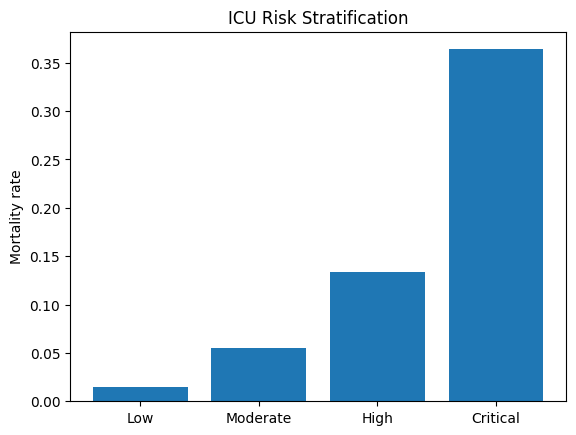

In [29]:
import matplotlib.pyplot as plt

rates = []

for i in range(4):

    idx = (preds >= bins[i]) & (preds < bins[i+1])

    rates.append(labels[idx].mean())

plt.bar(["Low","Moderate","High","Critical"], rates)

plt.ylabel("Mortality rate")
plt.title("ICU Risk Stratification")

plt.show()

In [30]:
state["model_state"] = model.state_dict()

torch.save(state, "E:/icu_project/session_state.pt")

print("Session updated")

Session updated


In [31]:
from sklearn.metrics import roc_auc_score

def evaluate_loader(loader):

    preds = []
    labels = []

    with torch.no_grad():

        for Xb, Mb, Db, Sb, yb in loader:

            Xb = Xb.to(device)
            Mb = Mb.to(device)
            Db = Db.to(device)
            Sb = Sb.to(device)

            logits = model(Xb, Mb, Db, Sb)

            prob = torch.sigmoid(logits).cpu().numpy()

            preds.extend(prob.flatten())
            labels.extend(yb.numpy())

    return roc_auc_score(labels, preds)


baseline_auc = evaluate_loader(test_loader)

print("Baseline ROC-AUC:", baseline_auc)

Baseline ROC-AUC: 0.8212510984605175


In [32]:
import numpy as np

num_features = X_test.shape[2]

importance_scores = []

for f in range(num_features):

    X_perm = X_test.clone()

    perm = torch.randperm(X_perm.size(0))

    X_perm[:,:,f] = X_perm[perm,:,f]

    dataset_perm = ICUDataset(
        X_perm,
        mask_test,
        delta_test,
        static_test,
        y_test
    )

    loader_perm = DataLoader(dataset_perm, batch_size=128)

    auc_perm = evaluate_loader(loader_perm)

    importance = baseline_auc - auc_perm

    importance_scores.append(importance)

    print("Feature", f, "AUC drop:", importance)

Feature 0 AUC drop: 0.0007050086951074785
Feature 1 AUC drop: -6.694021953523865e-05
Feature 2 AUC drop: 9.542541933782456e-05
Feature 3 AUC drop: 4.557631968371556e-05
Feature 4 AUC drop: -0.00039879279723231686
Feature 5 AUC drop: 0.009848757831649624
Feature 6 AUC drop: 0.006406321435540097
Feature 7 AUC drop: 7.1212999507297425e-06
Feature 8 AUC drop: -2.848519980236386e-05
Feature 9 AUC drop: 0.003829835113421165
Feature 10 AUC drop: 0.006662688233761149
Feature 11 AUC drop: 0.052633527934723534
Feature 12 AUC drop: -0.0003460951775979826
Feature 13 AUC drop: 0.000770524654652549
Feature 14 AUC drop: -1.8515379871408832e-05
Feature 15 AUC drop: -0.00010966801923895098
Feature 16 AUC drop: 0.0013459256906592776
Feature 17 AUC drop: -0.00028770051800330876
Feature 18 AUC drop: 0.000489945436599859
Feature 19 AUC drop: 0.0002677608781419538
Feature 20 AUC drop: 0.006760962173079088
Feature 21 AUC drop: -0.0009984062530710158
Feature 22 AUC drop: 0.0
Feature 23 AUC drop: 0.00057967381

In [33]:
importance_scores = np.array(importance_scores)

ranking = np.argsort(-importance_scores)

print("Top 15 most important variables")

for i in range(15):

    idx = ranking[i]

    print("Rank", i+1, "Feature", idx, "Importance:", importance_scores[idx])

Top 15 most important variables
Rank 1 Feature 11 Importance: 0.052633527934723534
Rank 2 Feature 74 Importance: 0.025197295615130955
Rank 3 Feature 5 Importance: 0.009848757831649624
Rank 4 Feature 38 Importance: 0.008831836198707088
Rank 5 Feature 20 Importance: 0.006760962173079088
Rank 6 Feature 10 Importance: 0.006662688233761149
Rank 7 Feature 6 Importance: 0.006406321435540097
Rank 8 Feature 35 Importance: 0.005853708559375392
Rank 9 Feature 9 Importance: 0.003829835113421165
Rank 10 Feature 26 Importance: 0.002979551899321975
Rank 11 Feature 53 Importance: 0.002391332523404177
Rank 12 Feature 27 Importance: 0.002358574543631642
Rank 13 Feature 24 Importance: 0.001600868228890051
Rank 14 Feature 80 Importance: 0.00157095876909763
Rank 15 Feature 16 Importance: 0.0013459256906592776


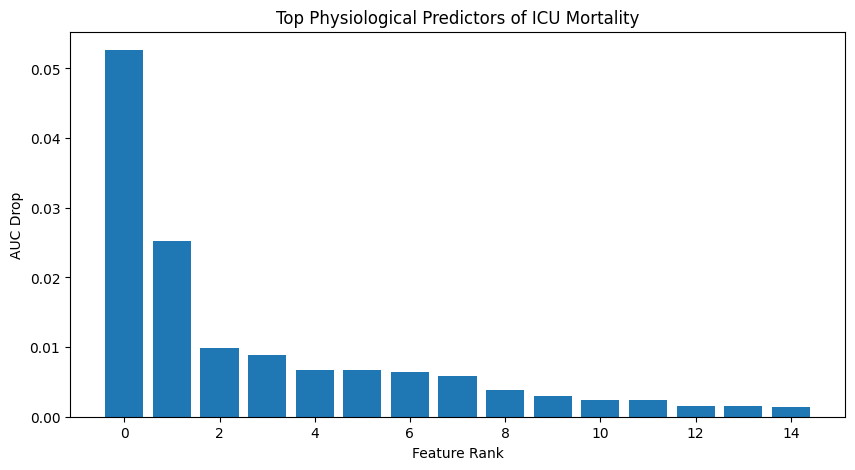

In [34]:
import matplotlib.pyplot as plt

topk = 15

plt.figure(figsize=(10,5))

plt.bar(range(topk), importance_scores[ranking[:topk]])

plt.xlabel("Feature Rank")
plt.ylabel("AUC Drop")
plt.title("Top Physiological Predictors of ICU Mortality")

plt.show()

In [35]:
np.save(
    "E:/icu_project/models/feature_importance.npy",
    importance_scores
)

print("Feature importance saved")

Feature importance saved


In [36]:
state["model_state"] = model.state_dict()

torch.save(state, "E:/icu_project/session_state.pt")

print("Session updated")

Session updated


In [37]:
feature_names = [
"Albumin","ALP","ALT","AST","Bilirubin","BUN","Cholesterol","Creatinine",
"FiO2","GCS","Glucose","HCO3","HCT","HR","K","Lactate","Mg","MAP",
"MechVent","Na","NIDiasABP","NIMAP","NISysABP","PaCO2","PaO2","pH",
"Platelets","RespRate","SaO2","SysABP","Temp","TroponinI","TroponinT",
"Urine","WBC","Weight"
]

In [38]:
import pandas as pd

results = []

for i,score in enumerate(importance_scores):

    var_name = feature_names[i % len(feature_names)]

    results.append((i, var_name, score))

df_importance = pd.DataFrame(
    results,
    columns=["FeatureIndex","Variable","Importance"]
)

df_importance = df_importance.sort_values(
    "Importance",
    ascending=False
)

print(df_importance.head(20))

    FeatureIndex     Variable  Importance
11            11         HCO3    0.052634
74            74          ALT    0.025197
5              5          BUN    0.009849
38            38          ALT    0.008832
20            20    NIDiasABP    0.006761
10            10      Glucose    0.006663
6              6  Cholesterol    0.006406
35            35       Weight    0.005854
9              9          GCS    0.003830
26            26    Platelets    0.002980
53            53          MAP    0.002391
27            27     RespRate    0.002359
24            24         PaO2    0.001601
80            80         FiO2    0.001571
16            16           Mg    0.001346
34            34          WBC    0.001035
40            40    Bilirubin    0.001014
13            13           HR    0.000771
63            63     RespRate    0.000739
0              0      Albumin    0.000705


In [39]:
agg_importance = df_importance.groupby("Variable")["Importance"].sum()

agg_importance = agg_importance.sort_values(ascending=False)

print(agg_importance.head(15))

Variable
HCO3           0.052839
ALT            0.034125
BUN            0.010403
NIDiasABP      0.006807
Cholesterol    0.006441
Weight         0.006194
Glucose        0.005694
GCS            0.003603
RespRate       0.003098
Platelets      0.003055
MAP            0.002104
Mg             0.002008
PaO2           0.001601
FiO2           0.001289
Bilirubin      0.001097
Name: Importance, dtype: float64


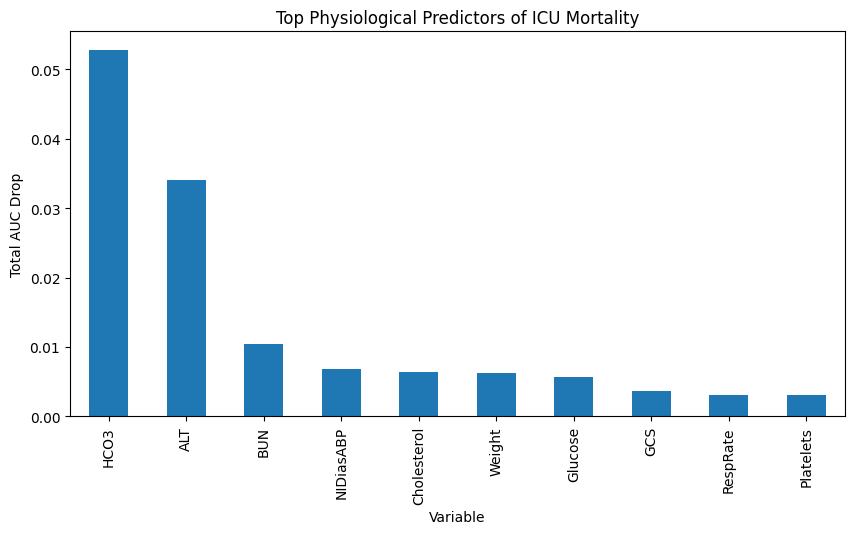

In [40]:
import matplotlib.pyplot as plt

top_vars = agg_importance.head(10)

plt.figure(figsize=(10,5))

top_vars.plot(kind="bar")

plt.ylabel("Total AUC Drop")
plt.title("Top Physiological Predictors of ICU Mortality")

plt.show()

In [41]:
df_importance.to_csv(
    "E:/icu_project/models/feature_importance_table.csv",
    index=False
)

agg_importance.to_csv(
    "E:/icu_project/models/variable_importance_summary.csv"
)

In [42]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(labels, preds)

f1 = (2 * precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best threshold: 0.44574314
Best F1: 0.48418971885182166


In [43]:
from sklearn.metrics import confusion_matrix

pred_labels = (preds >= best_threshold).astype(int)

cm = confusion_matrix(labels, pred_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1633  426]
 [  96  245]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(labels, pred_labels))

              precision    recall  f1-score   support

         0.0       0.94      0.79      0.86      2059
         1.0       0.37      0.72      0.48       341

    accuracy                           0.78      2400
   macro avg       0.65      0.76      0.67      2400
weighted avg       0.86      0.78      0.81      2400



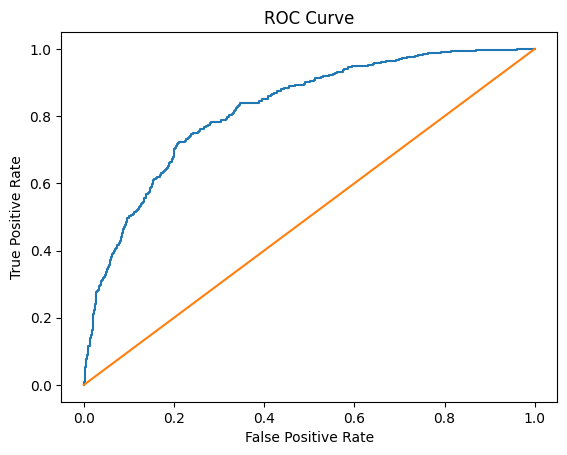

In [45]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(labels, preds)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

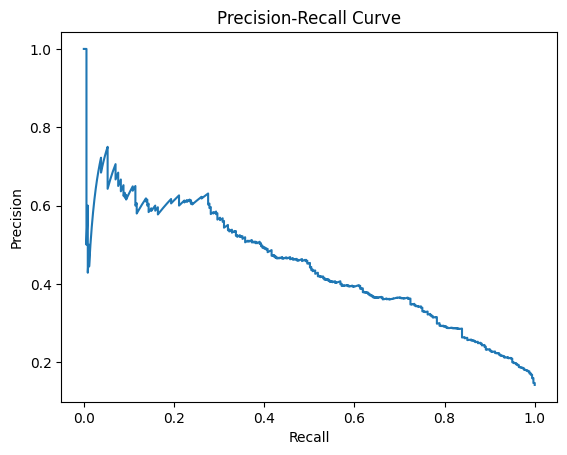

In [46]:
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

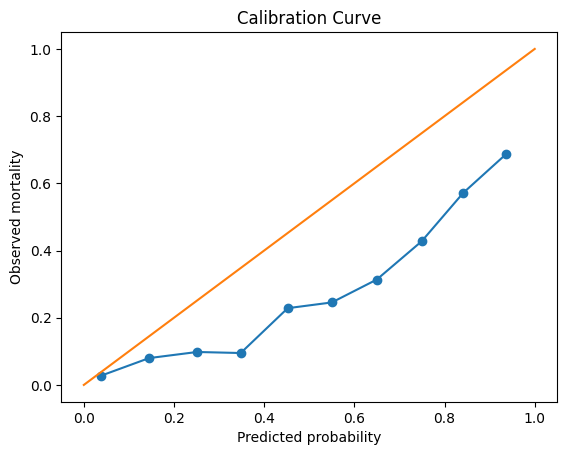

In [47]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(labels, preds, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1])
plt.xlabel("Predicted probability")
plt.ylabel("Observed mortality")
plt.title("Calibration Curve")
plt.show()

In [48]:
bins = np.percentile(preds, [0,25,50,75,100])

for i in range(4):

    idx = (preds >= bins[i]) & (preds < bins[i+1])

    mortality_rate = labels[idx].mean()

    print("Risk group", i+1, "mortality:", mortality_rate)

Risk group 1 mortality: 0.015
Risk group 2 mortality: 0.055
Risk group 3 mortality: 0.13333334
Risk group 4 mortality: 0.3639399


In [49]:
import pandas as pd

df_results = pd.DataFrame({
    "predicted_probability": preds,
    "true_label": labels
})

df_results.to_csv(
    "E:/icu_project/models/test_predictions.csv",
    index=False
)

print("Predictions saved")

Predictions saved


In [50]:
torch.save(
    model.state_dict(),
    "E:/icu_project/models/final_mortality_model.pt"
)

In [51]:
state["model_state"] = model.state_dict()
torch.save(state, "E:/icu_project/session_state.pt")